In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked,WikiId,Name_wiki,Age_wiki,Hometown,Boarded,Destination,Lifeboat,Body,Class
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,S,691.0,"Braund, Mr. Owen Harris",22.0,"Bridgerule, Devon, England",Southampton,"Qu'Appelle Valley, Saskatchewan, Canada",NaN,NaN,3.0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,C,90.0,"Cumings, Mrs. Florence Briggs (née Thayer)",35.0,"New York, New York, US",Cherbourg,"New York, New York, US",4,NaN,1.0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,S,865.0,"Heikkinen, Miss Laina",26.0,"Jyväskylä, Finland",Southampton,New York City,14?,NaN,3.0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,S,127.0,"Futrelle, Mrs. Lily May (née Peel)",35.0,"Scituate, Massachusetts, US",Southampton,"Scituate, Massachusetts, US",D,NaN,1.0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,S,627.0,"Allen, Mr. William Henry",35.0,"Birmingham, West Midlands, England",Southampton,New York City,NaN,NaN,3.0


In [3]:
## Data Exploration

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    float64
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  WikiId       889 non-null    float64
 13  Name_wiki    889 non-null    object 
 14  Age_wiki     887 non-null    float64
 15  Hometown     889 non-null    object 
 16  Boarded      889 non-null    object 
 17  Destination  889 non-null    object 
 18  Lifeboat     345 non-null    object 
 19  Body    

In [5]:
## Check Missing Value

In [6]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
WikiId           2
Name_wiki        2
Age_wiki         4
Hometown         2
Boarded          2
Destination      2
Lifeboat       546
Body           804
Class            2
dtype: int64

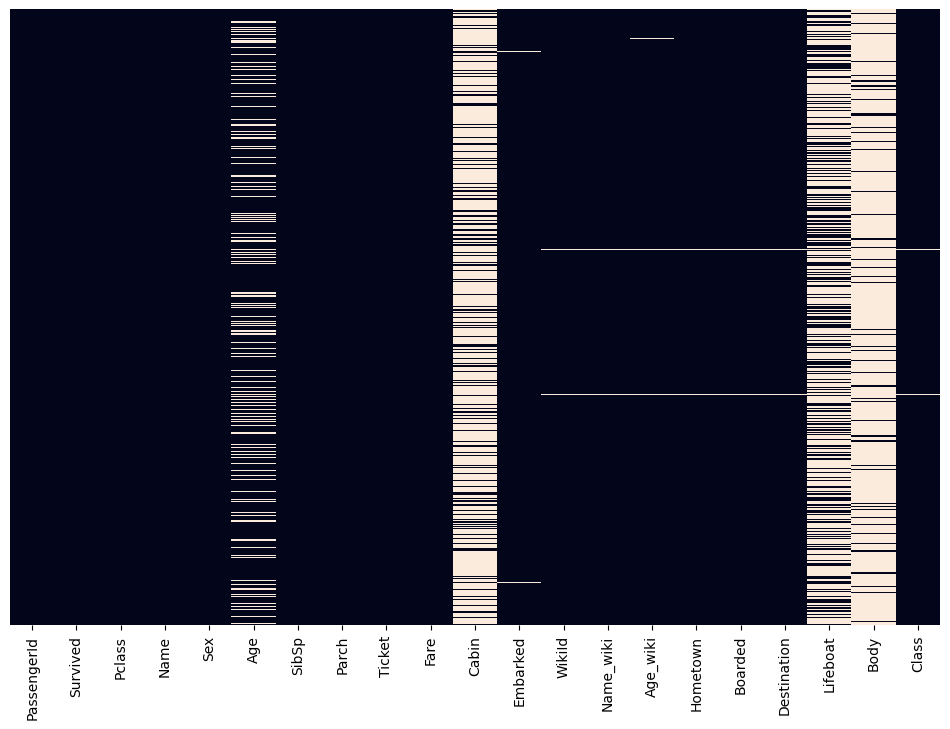

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.show()

In [8]:
Prediksi Pesawat Delay atau Tidak
Kolom target ==> Delay ==> Yes atau No ==> Klasifikasi
Klasifikasi ==> Ketika data Target berupa Kategori atau Numerikal Diskrit

Ada salah satu Features namanya
Minutes Delay ===> Meskipun nilai Korelasi Tinggi ==> Harus di drop
karena ketika ada Isinya..Target PAsti YES

Prediksi Karyawan akan Resign atau Stay
Kolom Target ==> Attrition ==> Yes - No

Ada Beberapa kolom yg memiliki Korelasi Tinggi tapi harus di drop

1. Termination Date ==> tanggal keluar
meskipun korelasi tinggi, harus di drop, karena jika ada isinya, pasti YES
2. Termination Reason ==> Alasan keluar
meskipun korelasi tinggi, harus di drop, karena jika ada isinya, pasti YES

SyntaxError: invalid syntax (3994102180.py, line 1)

In [9]:
## Pengecekan Imabalnce Data (Distribusi data Target)

In [10]:
### Hanya untuk Klasifikasi

In [11]:
df['Survived'].value_counts()

Survived
0.0    549
1.0    342
Name: count, dtype: int64

In [12]:
pd.crosstab(df['Survived'], columns='count', normalize=True) * 100

col_0,count
Survived,
0.0,61.616162
1.0,38.383838


In [13]:
Jika perbandingan target di atas 75% (salah satu) ==> Data Imbalanced
Data Imbalanced ==> Detector
Detector ==> Kita ingin mencari Target - Label tertentu

SyntaxError: invalid syntax (3487566250.py, line 1)

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292
WikiId,889.0,665.466817,380.796997,1.00,336.0000,672.0000,996.0,1314.0000
Age_wiki,887.0,29.322063,13.930089,0.42,20.0000,28.0000,38.0,74.0000
Class,889.0,2.307087,0.837713,1.00,2.0000,3.0000,3.0,3.0000


In [15]:
df.describe(include='O')

,Name,Sex,Ticket,Cabin,Embarked,Name_wiki,Hometown,Boarded,Destination,Lifeboat,Body
count,891,891,891,204,889,889,889,889,889,345,87
unique,891,2,681,147,3,889,437,4,234,22,87
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S,"Braund, Mr. Owen Harris","New York, New York, US",Southampton,New York City,15,175MB
freq,1,577,7,4,644,1,50,638,168,28,1


In [16]:
titanicDesc = []
for i in df.columns:
    titanicDesc.append([
    i,
    df[i].dtypes,
    df[i].isna().sum(),
    round((df[i].isna().sum()/len(df))*100, 2),
    df[i].nunique(),
    df[i].drop_duplicates().sample(2).values])

In [17]:
pd.DataFrame(data = titanicDesc,
            columns=['features',
                    'DataType',
                    'Null',
                    'NullPercentage',
                    'Unique',
                    'Sample'])

,features,DataType,Null,NullPercentage,Unique,Sample
0,PassengerId,int64,0,0.00,891,"[197, 648]"
1,Survived,float64,0,0.00,2,"[0.0, 1.0]"
2,Pclass,int64,0,0.00,3,"[1, 2]"
3,Name,object,0,0.00,891,"[Jensen, Mr. Hans Peder, Sadlier, Mr. Matthew]"
4,Sex,object,0,0.00,2,"[female, male]"
5,Age,float64,177,19.87,88,"[0.67, nan]"
6,SibSp,int64,0,0.00,7,"[3, 5]"
7,Parch,int64,0,0.00,7,"[4, 1]"
8,Ticket,object,0,0.00,681,"[S.O./P.P. 3, 2689]"
9,Fare,float64,0,0.00,248,"[93.5, 7.775]"


## mini EDA - Quick EDA
- Digunakan untuk Melakukan Features Selection - Pemilihan Fitur

## Domain Knowledge
- Melakukan Features Selection berdasarkan Domain Knowledge

In [18]:
# Kita drop Kolom Lifeboat dan Body karena kolom ini memiliki pengaruh yg terlalu pasti terhadapo target. Selain itu kolom ini memiliki Missing value diatas 50%
df.drop(columns=['Body', 'Lifeboat'], inplace=True)

In [19]:
## Kita drop Kolom Cabin dan Class karena kolom ini memiliki fungsi dan informasi yg serupa dengan kolom Pclass
## Kita memilih menggunakan Pclass, karena tidak terdapat Missing value di Kolom Pclass
df.drop(columns=['Cabin', 'Class'], inplace=True)

## Features Selection menggunakan EDA

In [20]:
## Buat Hipotesa Awal
- Pclass Berpengaruh terhadap Survival Rates
- Sex - Gender berpengaruh terhadap Survival rates
- Age/Usia berpengaruh terhadap survival Rates
- SibSp (Sibling - Spouse) berpengaruh terhadap survival Rates
- Parch (Parent - Chidren) berpengaruh terhadap Survival Rates
- Embarked - Boarded Berpengaruh terhadap Survival rates

SyntaxError: invalid syntax (708824218.py, line 2)

In [21]:
## Cek Pclass

In [22]:
df[['Pclass', 'Survived']].groupby('Pclass').count()

,Survived
Pclass,
1,216
2,184
3,491


In [23]:
(df[['Pclass', 'Survived']].groupby('Pclass').mean()*100).round(2)

,Survived
Pclass,
1,62.96
2,47.28
3,24.24


In [24]:
- Pclass 1 mamiliki Survival Rates paling tinggi => 62.96%
- Pclass berpengaruh terhadap survival rates

SyntaxError: invalid syntax (628436906.py, line 1)

In [25]:
## Cek Sex

In [26]:
df[['Sex', 'Survived']].groupby('Sex').mean()*100

,Survived
Sex,
female,74.203822
male,18.890815


- Sex - Female memiliki Survival Rates lebih tinggi => 74.2%
- Sex berpengaruh terhadap Survival rates

In [27]:
## Cek Age / Usia

In [28]:
- Melakukan Binning terhadap Age_wiki (Usia) agar lebih mudah dianalisa

SyntaxError: invalid syntax (2927034259.py, line 1)

In [29]:
#$## Handling missing value - FIll Missing value menggunakan rata-rat
df['Age_wiki'] = df['Age_wiki'] .fillna(df['Age_wiki'].mean())

In [30]:
age_bin = [0, 10, 20, 40, df['Age_wiki'].max()] ## membuat kelompok usia

In [31]:
labels = ['Kids', 'Teenager', 'Adult', 'Elder'] ## membuat label untuk kelompok usia

In [32]:
df['age_bin'] = pd.cut(df['Age_wiki'], bins=age_bin, labels=labels)

In [33]:
df[['age_bin', 'Survived']].groupby('age_bin').mean()*100

,Survived
age_bin,
Kids,56.944444
Teenager,32.258065
Adult,37.931034
Elder,37.426901


In [34]:
- Kelompok usia Kids (0-10) memiliki survival rates paling tinggi sebesar 56.94%
- Age berpengaruh terhadap Survival rates

SyntaxError: invalid syntax (2000320021.py, line 1)

In [35]:
## Cek SibSp

In [36]:
df[['SibSp', 'Survived']].groupby('SibSp').mean()*100

,Survived
SibSp,
0,34.539474
1,53.588517
2,46.428571
3,25.000000
4,16.666667
5,0.000000
8,0.000000


In [37]:
- Jumlah Sibling - Spouse berpengaruh terhadap survival rates, Jumlah SibSp = 1 paling tinggi Survival rates nya => 53.60%
- Jumlah SibSp dg survival rates paling rendah adalah yg memiliki SibSp 5 Keatas

SyntaxError: invalid syntax (1077516337.py, line 1)

In [38]:
## Cek Parch

In [39]:
df[['Parch', 'Survived']].groupby('Parch').mean()*100

,Survived
Parch,
0,34.365782
1,55.084746
2,50.000000
3,60.000000
4,0.000000
5,20.000000
6,0.000000


In [40]:
- Jumlah parent - children berpengaruh terhadap Survival Rates - Jumlah Parch = 3, Paling tinggi Survival Rates => 60%

SyntaxError: invalid syntax (3501104640.py, line 1)

In [41]:
## Cek Embarked - Boarded

In [42]:
df[['Embarked', 'Survived']].groupby('Embarked').mean()*100

,Survived
Embarked,
C,55.357143
Q,38.961039
S,33.695652


In [43]:
df[['Boarded', 'Survived']].groupby('Boarded').mean()*100

,Survived
Boarded,
Belfast,0.000000
Cherbourg,56.024096
Queenstown,38.157895
Southampton,34.326019


In [44]:
- Lokasi Embarked - Boarded berpengaruh terhadap Survival Rates, paling tinggi Survival Rates dari Cherbourg => 56%

SyntaxError: invalid syntax (2722046055.py, line 1)

In [45]:
## DataFrame for Initial Training

In [46]:
df_1 = df[['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked', 'Age_wiki']]

In [47]:
df_1.isna().sum()

Survived    0
Pclass      0
Sex         0
SibSp       0
Parch       0
Embarked    2
Age_wiki    0
dtype: int64

In [48]:
## Handling Missing Value

In [49]:
df_1['Embarked'].mode()

0    S
Name: Embarked, dtype: object

In [50]:
df_1['Embarked'] = df_1['Embarked'].fillna('S')

In [51]:
df_1.isna().sum()

Survived    0
Pclass      0
Sex         0
SibSp       0
Parch       0
Embarked    0
Age_wiki    0
dtype: int64

In [52]:
df_1.head()

,Survived,Pclass,Sex,SibSp,Parch,Embarked,Age_wiki
0,0.0,3,male,1,0,S,22.0
1,1.0,1,female,1,0,C,35.0
2,1.0,3,female,0,0,S,26.0
3,1.0,1,female,1,0,S,35.0
4,0.0,3,male,0,0,S,35.0


In [53]:
## Encoding

In [54]:
df_1['Sex'] = df_1['Sex'].map({'male':0, 'female' : 1})

In [55]:
pd.get_dummies(df_1, columns=['Embarked'], dtype='int32')

,Survived,Pclass,Sex,SibSp,Parch,Age_wiki,Embarked_C,Embarked_Q,Embarked_S
0,0.0,3,0,1,0,22.0,0,0,1
1,1.0,1,1,1,0,35.0,1,0,0
2,1.0,3,1,0,0,26.0,0,0,1
3,1.0,1,1,1,0,35.0,0,0,1
4,0.0,3,0,0,0,35.0,0,0,1
...,...,...,...,...,...,...,...,...,...
886,0.0,2,0,0,0,27.0,0,0,1
887,1.0,1,1,0,0,19.0,0,0,1
888,0.0,3,1,1,2,7.0,0,0,1
889,1.0,1,0,0,0,26.0,1,0,0


In [56]:
df_1 = pd.get_dummies(df_1, columns=['Embarked'], dtype='int32')

In [57]:
df_1.head()

,Survived,Pclass,Sex,SibSp,Parch,Age_wiki,Embarked_C,Embarked_Q,Embarked_S
0,0.0,3,0,1,0,22.0,0,0,1
1,1.0,1,1,1,0,35.0,1,0,0
2,1.0,3,1,0,0,26.0,0,0,1
3,1.0,1,1,1,0,35.0,0,0,1
4,0.0,3,0,0,0,35.0,0,0,1


In [58]:
df_1.isna().sum()

Survived      0
Pclass        0
Sex           0
SibSp         0
Parch         0
Age_wiki      0
Embarked_C    0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [59]:
## Cek Korelasi ==> Optional karena kita sudah melakukan Features Selection menggunakan EDA

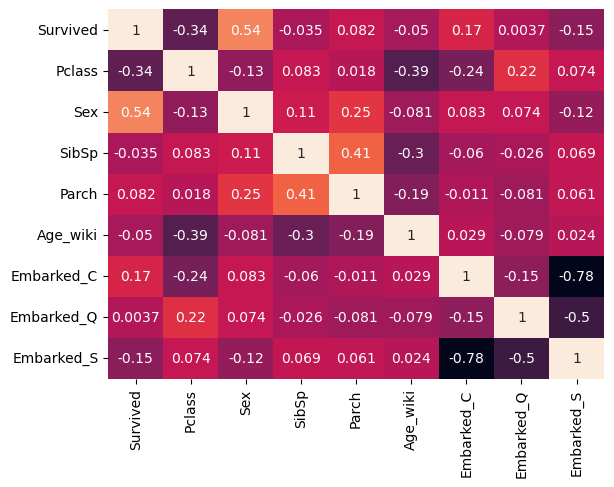

In [60]:
sns.heatmap(df_1.corr(), annot=True, cbar=False)
plt.show()

In [61]:
- Karena jumlah features cukup sedikit dan karena kita telah melakukan Quick EDA untuk mengetahui pengaruh features terhadap target,
sehingga, sementara kita akan gunakan semua features, meskipun memiliki korelasi rendah

SyntaxError: invalid syntax (3255726481.py, line 1)

In [62]:
## Machine Learning Modelling

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [64]:
## Splitting Data

In [73]:
X = df_1.drop(columns='Survived')
y = df_1['Survived']

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.80, stratify=y, random_state=42)

In [75]:
- Train test split ketika dilakukan untuk Kasus KLASIFIKASI, HARUS Menggunakan parameter Stratify. Agar ketika melakukan SPlitting bisa dilakukan Fair antar Class/target/label

SyntaxError: invalid syntax (4000958904.py, line 1)

In [76]:
X_train.head()

,Pclass,Sex,SibSp,Parch,Age_wiki,Embarked_C,Embarked_Q,Embarked_S
692,3,0,0,0,37.0,0,0,1
481,2,0,0,0,37.0,0,0,1
527,1,0,0,0,57.0,0,0,1
855,3,1,0,1,18.0,0,0,1
801,2,1,1,1,31.0,0,0,1


In [77]:
X_test.head()

,Pclass,Sex,SibSp,Parch,Age_wiki,Embarked_C,Embarked_Q,Embarked_S
565,3,0,2,0,24.0,0,0,1
160,3,0,0,1,44.0,0,0,1
553,3,0,0,0,22.0,1,0,0
860,3,0,2,0,41.0,0,0,1
241,3,1,1,0,18.0,0,1,0


In [78]:
## Base Model

In [79]:
model_LR = LogisticRegression()

In [80]:
model_LR.fit(X_train, y_train)

LogisticRegression()

In [81]:
model_LR.score(X_train, y_train) ## Nilai Accuracy

0.8033707865168539

In [82]:
model_LR.score(X_test, y_test)

0.8100558659217877

## Evaluation Metrics for Classification

In [84]:
y_test

565    0.0
160    0.0
553    1.0
860    0.0
241    1.0
      ... 
880    1.0
91     0.0
883    0.0
473    1.0
637    0.0
Name: Survived, Length: 179, dtype: float64

In [85]:
model_LR.predict(X_test)

array([0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1.,
       0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1.,
       0., 1., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 1., 1., 0.,
       0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1.,
       0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 1.,
       1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0.,
       1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1.,
       1., 0., 1., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1.,
       0., 0., 1., 0., 1., 0., 0., 1., 0.])

In [86]:
## Evaluation Metrics Training

In [87]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

In [88]:
y_pred_tr = model_LR.predict(X_train)

In [89]:
accuracy_score(y_train, y_pred_tr)

0.8033707865168539

In [90]:
recall_score(y_train, y_pred_tr)

0.7106227106227107

In [91]:
precision_score(y_train, y_pred_tr)

0.7607843137254902

In [92]:
## Evaluation Metrics Testing

In [93]:
y_pred_ts = model_LR.predict(X_test)

In [94]:
accuracy_score(y_test, y_pred_ts)

0.8100558659217877

In [95]:
recall_score(y_test, y_pred_ts, pos_label=0)

0.6811594202898551

In [96]:
precision_score(y_test, y_pred_ts)

0.7966101694915254